## Pathfinder 2e encounter builder: Comparing character damage output to monster strength

character damage simulation predictions as a  "standard curve" for the target ac performance levels for each moster
* How does each monster (based on AC) perform compared to the expected curve?
* How does the monster 'last' (damage output) through 5 rounds?
* IF the monster is defeated in LESS than the standard curve (5 rounds ) => "easy" encounter
* IF the monster is NOT defeated in the standard curve (more than 5 rounds) => "hard" encounter
* IF the monster falls along the standard curve (defeated in 5 rounds) => "moderate" encounter

* How does each monster fair between classes? Is there monsters that are more or less 'vulnerable' to specific classes?

In [1]:
#Import libraries 
import pandas as pd
import numpy as np
import requests
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as plt


import requests
from bs4 import BeautifulSoup
import pandas as pd
from io import StringIO
import re
import random

import warnings
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

### Open monster/bestiary information and prepare for relevant information

total monsters: 413
Total monster under 30 AC: 314


,Unnamed: 0,Name,Level,AC,Low Save,Hi Save,Median Save,Fort,Ref,Will,HP,Atk,DC
240,240,Gnoll Sergeant,4.0,21.0,+8,12.0,10.0,12.0,+10,8.0,60.0,14.0,NaN
100,100,Satyr,4.0,19.0,+9,12.0,11.0,9.0,+11,12.0,80.0,14.0,21.0
306,306,Drow Fighter,1.0,18.0,+4,9.0,7.0,7.0,+9,4.0,18.0,9.0,14.0
333,333,Cockatrice,3.0,19.0,+6,11.0,8.0,8.0,+11,6.0,45.0,13.0,20.0
36,36,War Pony,1.0,16.0,+5,8.0,7.0,8.0,+7,5.0,20.0,7.0,NaN
118,118,Quatoid,7.0,25.0,+13,18.0,15.0,13.0,+15,18.0,120.0,16.0,27.0
356,356,Bugbear Thug,2.0,17.0,+5,9.0,8.0,9.0,+8,5.0,34.0,10.0,NaN
95,95,Sea Hag,3.0,19.0,+8,11.0,10.0,11.0,+8,10.0,45.0,12.0,20.0
192,192,Kobold Dragon Mage,2.0,17.0,+4,7.0,7.0,4.0,+7,7.0,25.0,7.0,20.0
297,297,Duskwalker Ghost Hunter,4.0,21.0,+9,12.0,10.0,9.0,+12,10.0,56.0,14.0,NaN


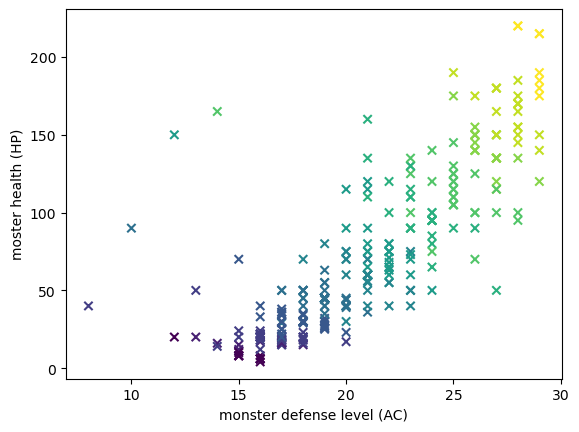

In [2]:
monster_stat= pd.read_csv('../output_data/bestiary_stats.csv')

#filter only the monsters with AC UP to 30 or lower
monster_stat_AC = monster_stat[monster_stat['AC']<30]
print('total monsters:', len(monster_stat))
print("Total monster under 30 AC:", len(monster_stat_AC))
plt.scatter(monster_stat_AC['AC'], 
            monster_stat_AC['HP'], 
            marker='x', 
            c=monster_stat_AC['Level'])
plt.xlabel('monster defense level (AC)')
plt.ylabel('moster health (HP)')

#view dataframe 
monster_stat_AC.sample(10)

### Open encounter simulation data

In [3]:
sim_encounter= pd.read_csv('../output_data/simualtion_results_ac10-30.csv')
sim_encounter.sample(3)

,Unnamed: 0,attack_sucess_1,attack_sucess_2,total_dmg,avg_dmg,attack_crit_status_1,attack_crit_status_2,build_name,build_level,target_ac,encounter_num,ancestry,class_build
1848,8,0.0,0.0,0.0,0.0,0.0,0.0,human-dex barbarian strength,1,22,8,human-dex,barbarian
4923,3,0.4,0.6,29.0,5.8,0.0,0.0,orc-str fighter strength,1,16,3,orc-str,fighter
4183,3,0.0,0.2,9.0,1.8,0.0,0.0,human-str fighter strength,1,19,3,human-str,fighter


### Visualize monster performance (by AC) on the 'standard curve' for a given build

halfling


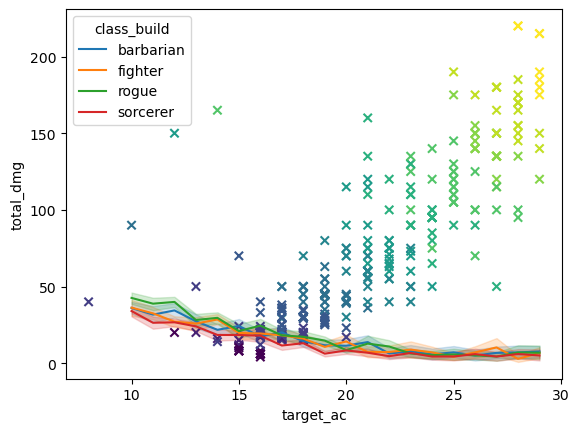

In [4]:
ancestry_list_options= sim_encounter['ancestry'].unique().tolist()
print(ancestry_list_options[2])

filter_graph = sim_encounter[sim_encounter['ancestry'] == ancestry_list_options[2]]
sns.lineplot(x="target_ac", y="total_dmg", hue="class_build", data=filter_graph)

#add moster data to the plot based on AC and HP 
plt.scatter(monster_stat_AC['AC'], 
            monster_stat_AC['HP'], 
            marker='x', 
            c=monster_stat_AC['Level'])

### Calculate the total damage output for a party of 4 character builds
#### Classify monster difficulty based on the comparrison between party output 
* below minimum -> trivial
* below 25th percentile -> easy
* 25th to 75th -> moderate
* 75th to max -> hard
* max and above -> impossible 

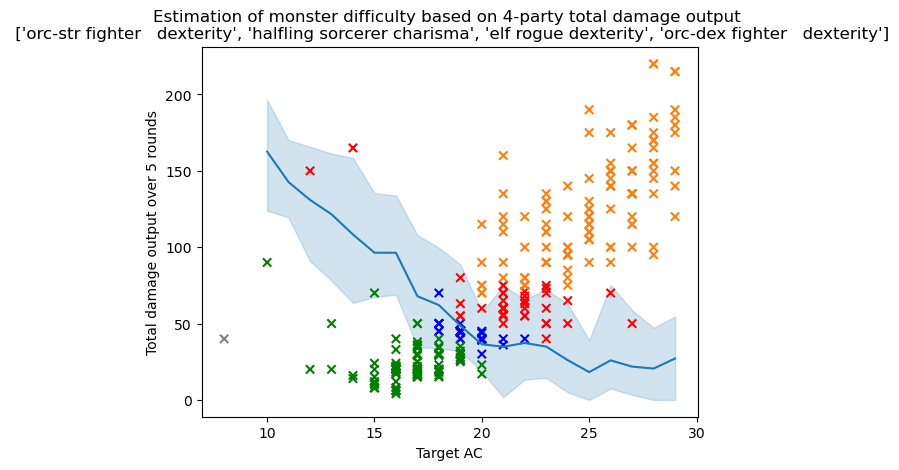

In [5]:
#######
### generate a random 4-party composition 
########

all_build_options = sim_encounter['build_name'].unique().tolist()

#create a random number generator and pull out 4 random numbers
random_party_combo= random.choices(range(0, len(all_build_options)), k=4) 

random_party_build_combo= []
for pick in random_party_combo:
    random_party_build_combo.append(all_build_options[pick])

####
#Calulate total round of damage from simulation dataset based on the 4 party build members
####

#filter out only these builds from the simulation data 
four_party_sim= sim_encounter[sim_encounter['build_name'].isin(random_party_build_combo)]

#for EACH AC and add up all the damage from EACH ENCOUNTER
range_target_ac= four_party_sim['target_ac'].unique().tolist()
#make a list for the number of encounter simulations 
encounter_num_list = four_party_sim['encounter_num'].unique().tolist()

party_combo_enc_dmg= pd.DataFrame(columns=encounter_num_list)
for ac_choice in  range_target_ac:
    #filter out simulations for that one AC
    party_ac_filter = four_party_sim[four_party_sim['target_ac'] == ac_choice]
    #for each encounter number, calculate the total damage from the whole party 
    enc_dmg_total = party_ac_filter.groupby('encounter_num')['total_dmg'].sum().to_list()
    # #Save this into a new dataframe with the AC
    party_combo_enc_dmg.loc[f'{ac_choice}'] = enc_dmg_total

#####
# create a visual to see the overlap between party damage output and monster hitpoint total 
#####
#create the melted dataframe to match the expected formating 
melt_enc = pd.melt(party_combo_enc_dmg.T)
#convert the AC ('variable') into an int so it lines up with monster stat correctly 
melt_enc['variable']= melt_enc['variable'].astype(int)

#graph the summary chart of party damage output
sns.lineplot(x='variable', 
             y="value", 
             data=melt_enc, 
             #use "pi" (prediction interval) to see full range of outcomes for overlaping with monster points 
             errorbar="pi") ;


#####
# Compare monster dataset to party results and catergorize monster challenge rating 
#####
### Calculate summary statistics from simulation data -> min, max, 25-75 quartile
party_combo_dmg_ac= party_combo_enc_dmg.T
party_combo_enc_describe = party_combo_dmg_ac.describe().T

challenge_status= []

#compare each monster to the party composition and calculate challenge ranking 
for monster in range (len(monster_stat_AC)):
    
    #pull out monster AC
    monster_ac = monster_stat_AC.iloc[monster]['AC']

    if monster_ac >= 10:
        #Compare to party summary stats
        summary_stats = party_combo_enc_describe.loc[f'{int(monster_ac)}']
    
        #pull out monster HP 
        monster_hp = monster_stat_AC.iloc[monster]['HP']
    
        #check conditionals
        if monster_hp < summary_stats['25%']:
            challenge_status.append('easy')
        elif monster_hp >= summary_stats['25%'] and  monster_hp <= summary_stats['75%']:
            challenge_status.append('moderate')
        elif monster_hp > summary_stats['75%'] and  monster_hp <= summary_stats['max']:
            challenge_status.append('hard')
        elif monster_hp > summary_stats['max']:
            challenge_status.append('impossible')
        else:
            challenge_status.append('error')
    else: 
        challenge_status.append('outside range')

#add it as a new column 
monster_stat_AC['challenge_rank'] = challenge_status

#convert it to a color value using a dictionary 
color_dict= {'easy': 'green', 'moderate': 'blue', 'hard': 'red', 'impossible': 'tab:orange', 'outside range': 'gray'}
monster_stat_AC['challenge_rank']= monster_stat_AC['challenge_rank'].replace(color_dict)

#Add in the monster chart values 
plt.scatter(monster_stat_AC['AC'], 
            monster_stat_AC['HP'], 
            marker='x', 
            c=monster_stat_AC['challenge_rank']);
#add variable name descriptions 
plt.xlabel('Target AC');
plt.ylabel('Total damage output over 5 rounds');
plt.title(f"Estimation of monster difficulty based on 4-party total damage output \n {random_party_build_combo}");
#save figure 
plt.savefig(f'../output_figures/{random_party_build_combo}_damage_monster.png')